Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [12]:
import pandas as pd

df = pd.read_csv("Employee_Attrition_500K.csv")

print("Rows loaded:", len(df))
print("Columns:", len(df.columns))

Rows loaded: 87932
Columns: 20


Data Understanding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87932 entries, 0 to 87931
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Employee_ID             87932 non-null  int64 
 1   Age                     87932 non-null  int64 
 2   Gender                  87932 non-null  object
 3   Department              87932 non-null  object
 4   Job_Role                87932 non-null  object
 5   Education               87932 non-null  object
 6   Marital_Status          87932 non-null  object
 7   Monthly_Income          87932 non-null  int64 
 8   Years_at_Company        87932 non-null  int64 
 9   Job_Satisfaction        87932 non-null  int64 
 10  Work_Life_Balance       87932 non-null  int64 
 11  Overtime                87932 non-null  object
 12  Performance_Rating      87932 non-null  int64 
 13  Training_Hours          87932 non-null  int64 
 14  Remote_Work_Days        87932 non-null  int64 
 15  Ab

In [ ]:
df.describe()

,Employee_ID,Age,Monthly_Income,Years_at_Company,Job_Satisfaction,Work_Life_Balance,Performance_Rating,Training_Hours,Remote_Work_Days,Absenteeism_Days,Salary_Hike_Percent,Manager_Rating
count,87932.000000,87932.000000,87932.000000,87932.000000,87932.000000,87932.000000,87932.000000,87932.000000,87932.000000,87932.000000,87932.000000,87932.000000
mean,43966.500000,40.548003,112578.738866,14.995872,2.991744,3.002331,3.004447,49.989492,9.963313,7.471921,12.485819,2.993313
std,25383.926272,11.523166,50524.129927,8.957064,1.412983,1.412928,1.414227,29.175778,6.064516,4.612971,7.488350,1.417932
min,1.000000,21.000000,25000.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,21983.750000,31.000000,68743.250000,7.000000,2.000000,2.000000,2.000000,25.000000,5.000000,3.000000,6.000000,2.000000
50%,43966.500000,41.000000,112662.000000,15.000000,3.000000,3.000000,3.000000,50.000000,10.000000,7.000000,12.000000,3.000000
75%,65949.250000,50.000000,156328.750000,23.000000,4.000000,4.000000,4.000000,75.000000,15.000000,11.000000,19.000000,4.000000
max,87932.000000,60.000000,199997.000000,30.000000,5.000000,5.000000,5.000000,100.000000,20.000000,15.000000,25.000000,5.000000


In [ ]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Department,0
Job_Role,0
Education,0
Marital_Status,0
Monthly_Income,0
Years_at_Company,0
Job_Satisfaction,0


In [13]:
df.duplicated().sum()

np.int64(0)

Data Cleaning

In [ ]:
df.drop_duplicates(inplace=True)
print(df.shape)

(87932, 20)


Create Derived Variables

Salary Band

In [ ]:
df["Salary_Band"] = pd.cut(
    df["Monthly_Income"],
    bins=[0, 50000, 100000, float('inf')],
    labels=["Low", "Medium", "High"]
)

Retention Risk Score

In [ ]:
df["Risk_Score"] = np.where(
    (df["Job_Satisfaction"] <= 2) &
    (df["Work_Life_Balance"] <= 2) &
    (df["Overtime"] == "Yes"),
    "High Risk",
    "Low Risk"
)

KPI designs


Total Employees

In [ ]:
total_employees = len(df)

print("Total Employees:", total_employees)

Total Employees: 87932


Attrition Rate

In [ ]:
attrition_rate = (
    df["Attrition"].value_counts(normalize=True)["Yes"]
) * 100

print("Attrition Rate:", round(attrition_rate,2))

Attrition Rate: 19.93


Retention Rate

In [ ]:
retention_rate = 100 - attrition_rate

print("Retention Rate:", round(retention_rate,2))

Retention Rate: 80.07


Average Tenure

In [ ]:
avg_tenure = df["Years_at_Company"].mean()

print("Average Tenure:", round(avg_tenure,2))

Average Tenure: 15.0


Job Satisfaction

In [ ]:
job_satisfaction = df["Job_Satisfaction"].mean()

print("Job Satisfaction:", round(job_satisfaction,2))

Job Satisfaction: 2.99


Average Income

In [ ]:
avg_income = df["Monthly_Income"].mean()

print("Average Income:", round(avg_income,2))

Average Income: 112578.74


Overtime Percentage

In [ ]:
overtime_pct = (
    df["Overtime"].value_counts(normalize=True)["Yes"]
) * 100

print("Overtime %:", round(overtime_pct,2))

Overtime %: 49.98


High Risk Employee Count

In [ ]:
high_risk_count = df[df["Risk_Score"] == "High Risk"].shape[0]

print("High Risk Employee Count:", high_risk_count)

High Risk Employee Count: 7201


 Analytics Investigation  

Department Distribution

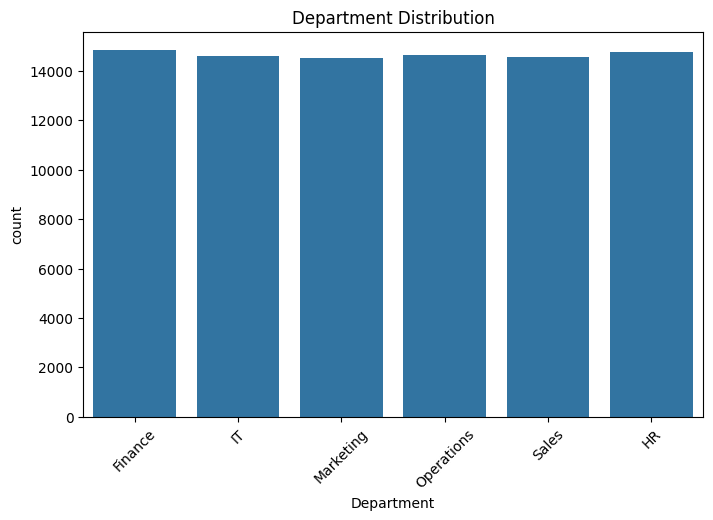

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Department",
    data=df
)

plt.xticks(rotation=45)
plt.title("Department Distribution")
plt.show()

Department vs Attrition

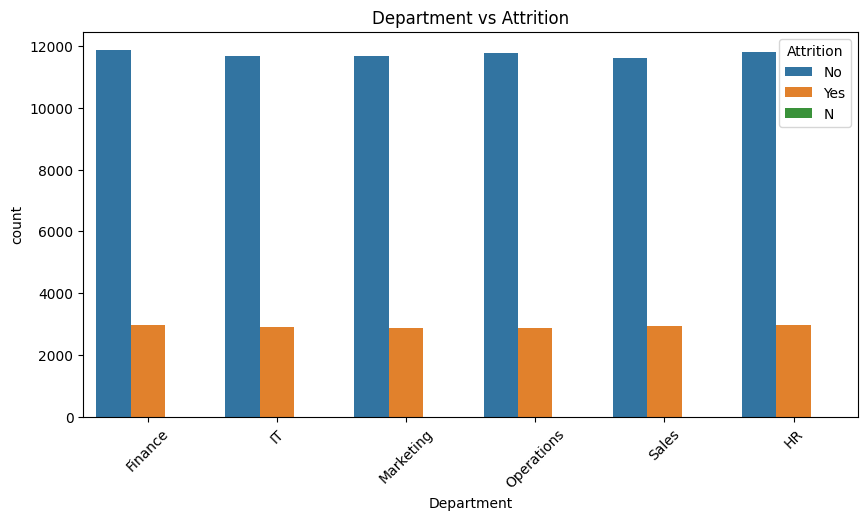

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Department",
    hue="Attrition",
    data=df
)

plt.xticks(rotation=45)
plt.title("Department vs Attrition")
plt.show()

Salary Band vs Attrition

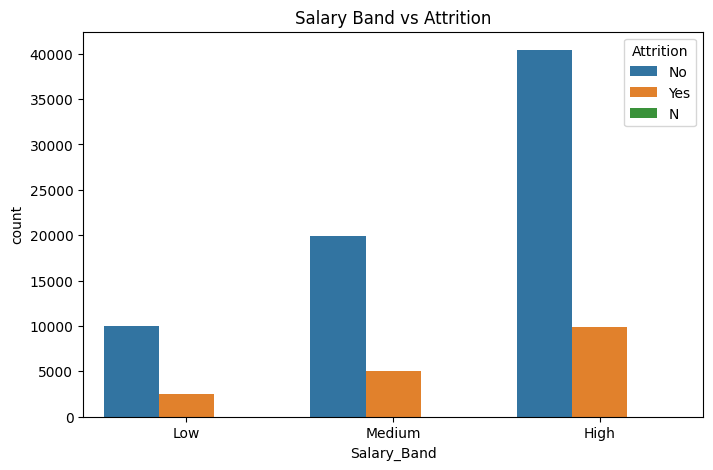

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Salary_Band",
    hue="Attrition",
    data=df
)

plt.title("Salary Band vs Attrition")
plt.show()

Work-Life Balance vs Attrition

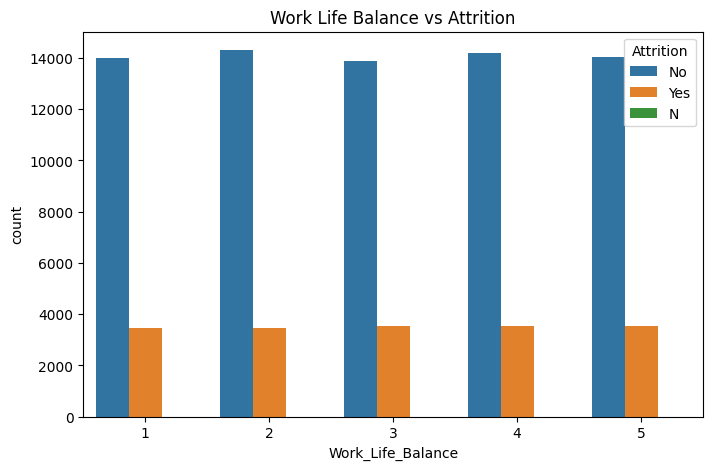

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Work_Life_Balance",
    hue="Attrition",
    data=df
)

plt.title("Work Life Balance vs Attrition")
plt.show()

Overtime vs Attrition

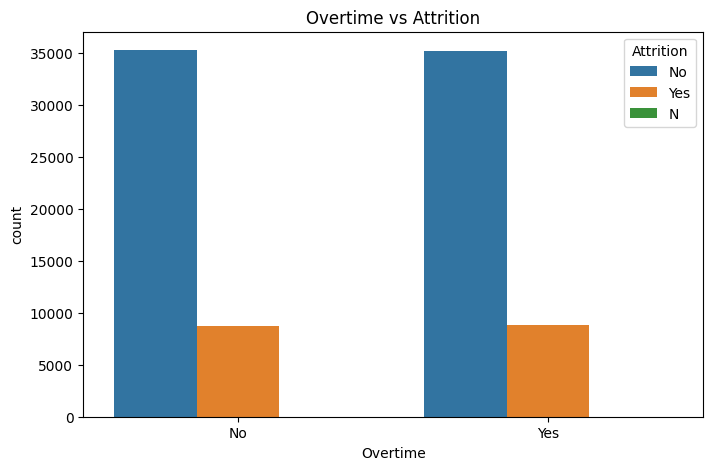

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Overtime",
    hue="Attrition",
    data=df
)

plt.title("Overtime vs Attrition")
plt.show()

Job Satisfaction vs Attrition

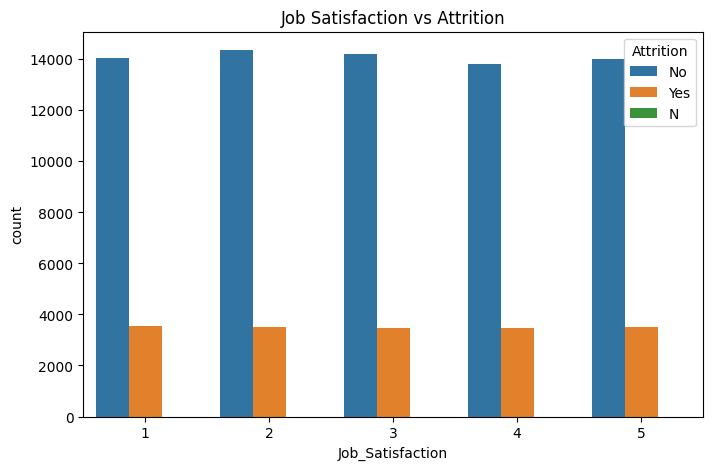

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Job_Satisfaction",
    hue="Attrition",
    data=df
)

plt.title("Job Satisfaction vs Attrition")
plt.show()

Correlation Analysis

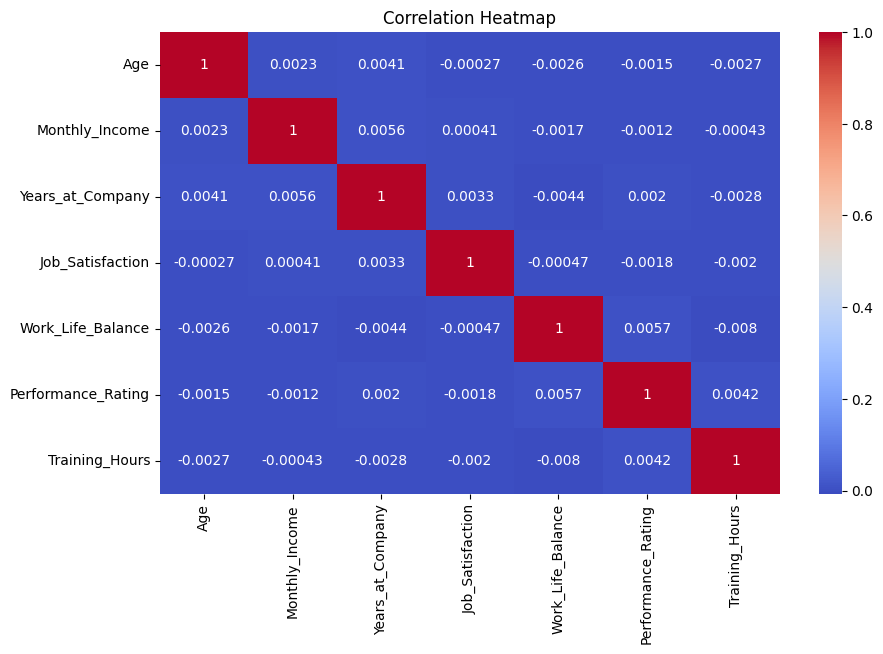

In [ ]:
numeric_cols = [
    "Age",
    "Monthly_Income",
    "Years_at_Company",
    "Job_Satisfaction",
    "Work_Life_Balance",
    "Performance_Rating",
    "Training_Hours"
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Employee Segmentation

High Risk Employees

In [ ]:
high_risk = df[
    df["Risk_Score"] == "High Risk"
]

print(high_risk.shape)

(7201, 22)


High Performers

In [ ]:
high_performers = df[
    df["Performance_Rating"] >= 4
]

print(high_performers.shape)

(35341, 22)


Long-Term Employees

In [ ]:
long_term = df[
    df["Years_at_Company"] >= 10
]

print(long_term.shape)

(59576, 22)


Overtime Employees

In [ ]:
overtime_emp = df[df["Overtime"] == "Yes"]

print("Overtime Employees:", overtime_emp.shape[0])

Overtime Employees: 43946


Dissatisfied Employees

In [ ]:
dissatisfied_emp = df[
    df["Job_Satisfaction"] <= 2
]

print("Dissatisfied Employees:",
      dissatisfied_emp.shape[0])


Dissatisfied Employees: 35456


Behavioral Difference Analysis

In [ ]:
comparison = pd.DataFrame({
    "Group": [
        "High Risk",
        "High Performers",
        "Long-Term",
        "Overtime",
        "Dissatisfied"
    ],

    "Avg Income": [
        high_risk["Monthly_Income"].mean(),
        high_performers["Monthly_Income"].mean(),
        long_term["Monthly_Income"].mean(),
        overtime_emp["Monthly_Income"].mean(),
        dissatisfied_emp["Monthly_Income"].mean()
    ],

    "Avg Job Satisfaction": [
        high_risk["Job_Satisfaction"].mean(),
        high_performers["Job_Satisfaction"].mean(),
        long_term["Job_Satisfaction"].mean(),
        overtime_emp["Job_Satisfaction"].mean(),
        dissatisfied_emp["Job_Satisfaction"].mean()
    ],

    "Avg Work-Life Balance": [
        high_risk["Work_Life_Balance"].mean(),
        high_performers["Work_Life_Balance"].mean(),
        long_term["Work_Life_Balance"].mean(),
        overtime_emp["Work_Life_Balance"].mean(),
        dissatisfied_emp["Work_Life_Balance"].mean()
    ],

    "Attrition Rate (%)": [
        (high_risk["Attrition"].eq("Yes").mean()) * 100,
        (high_performers["Attrition"].eq("Yes").mean()) * 100,
        (long_term["Attrition"].eq("Yes").mean()) * 100,
        (overtime_emp["Attrition"].eq("Yes").mean()) * 100,
        (dissatisfied_emp["Attrition"].eq("Yes").mean()) * 100
    ]
})

print(comparison.round(2))

             Group  Avg Income  Avg Job Satisfaction  Avg Work-Life Balance  \
0        High Risk   112695.93                  1.50                   1.51   
1  High Performers   112453.88                  2.98                   3.01   
2        Long-Term   112665.32                  2.99                   3.00   
3         Overtime   112451.07                  2.98                   3.00   
4     Dissatisfied   112711.71                  1.50                   3.00   

   Attrition Rate (%)  
0               18.96  
1               20.09  
2               19.91  
3               19.99  
4               19.92  


Visualization

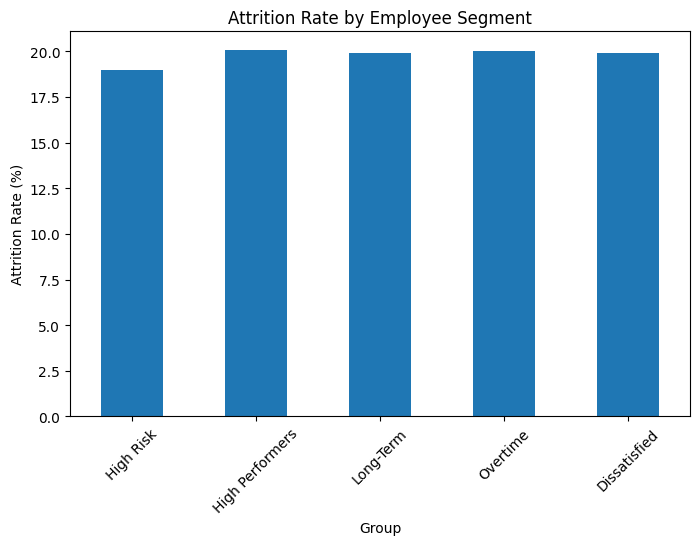

In [ ]:
import matplotlib.pyplot as plt

comparison.set_index("Group")["Attrition Rate (%)"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Attrition Rate by Employee Segment")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)
plt.show()